In [65]:
import spacy
import pandas as pd
import spacy.lang.yo as yo
from spacy.lang.en.stop_words import STOP_WORDS as en_sw
import numpy as np
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical

In [66]:
nlp = spacy.blank('xx')

In [ ]:
pid_df = pd.read_csv('pidgin_tweets.csv')
pid_df.head()

,tweet,label
0,joke of a government na thunder way de do pres...,negative
1,it will not better for d handlers if this fpl ...,negative
2,e be like say oga chairman true colour don dey...,negative
3,i no fit marry man wey dey fight for nxt sha n...,negative
4,its so pathetic why dont we really think abt o...,negative


In [68]:
pid_df.shape

(60556, 2)

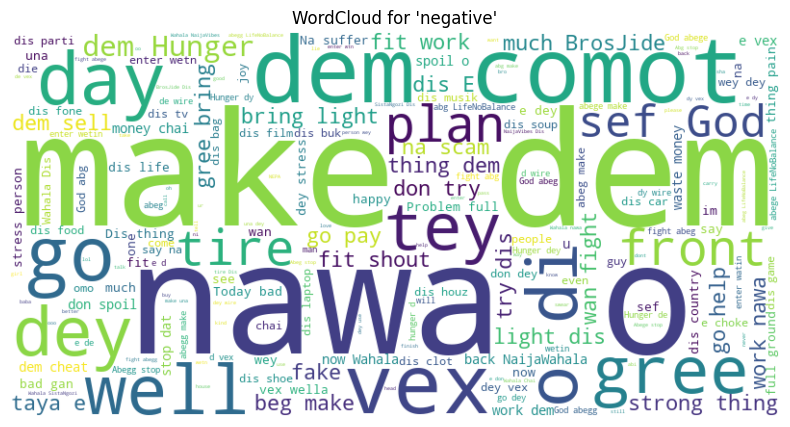

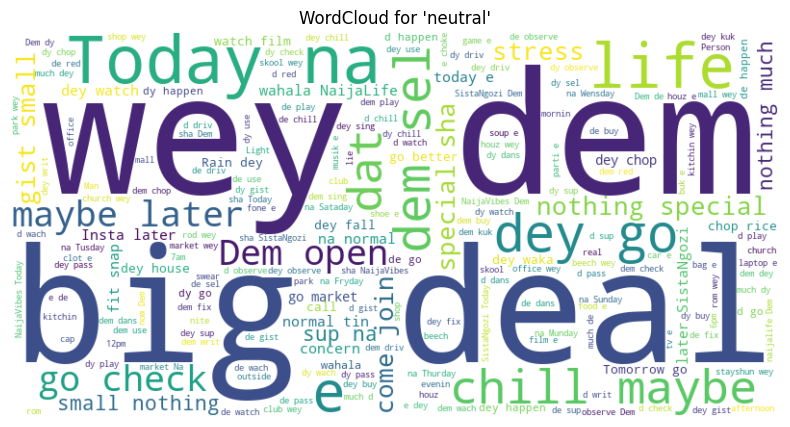

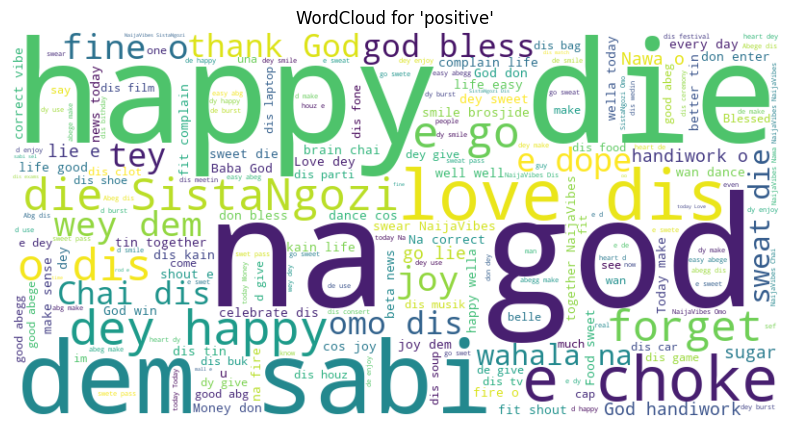

In [69]:
for label in pid_df["label"].unique():
    text = " ".join(pid_df[pid_df["label"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

In [70]:
pidsw = pd.read_csv('pcm.csv')
def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    text = re.sub(r'http\S+|@\w+|#\w+|\bRT\b|"{2,}', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[.]{2,}', ' ', text)
    text = re.sub(r'[\!\?\:\.\,]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp(text)
    tokens = [
        token.text.lower() for token in doc 
        if token.text.lower() not in pidsw.word
        and token.text not in en_sw
        and token.text not in string.punctuation
        and len(token.text.strip()) > 1
        and not token.text.isdigit()
    ]

    return " ".join(tokens).strip() or "empty"

In [71]:
pid_df['clean_text'] = pid_df.tweet.apply(preprocess_text)

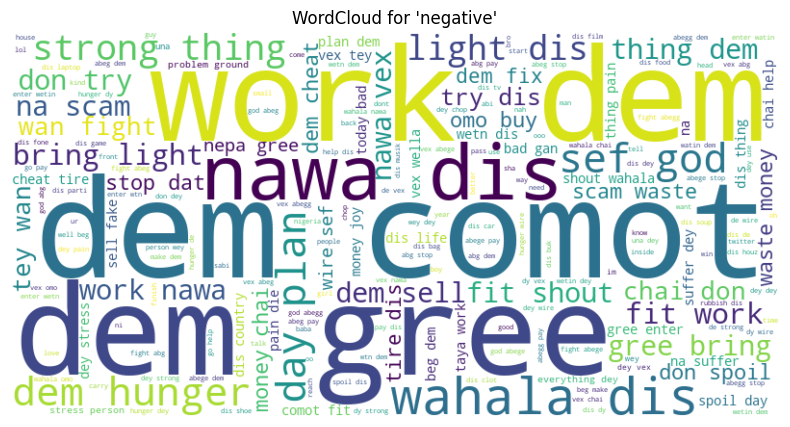

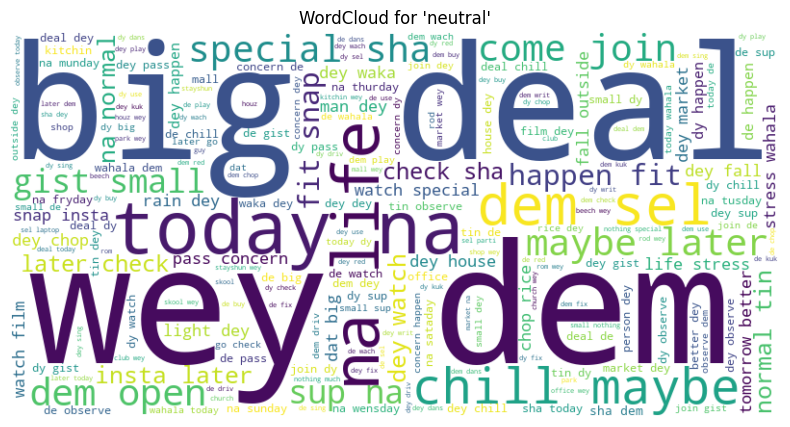

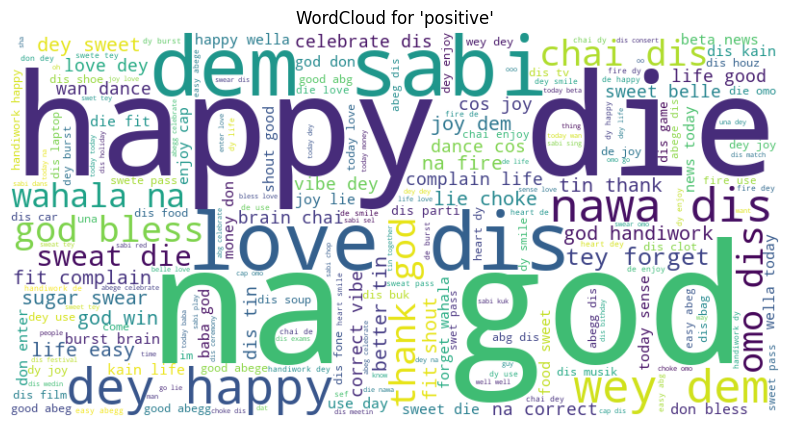

In [72]:
for label in pid_df["label"].unique():
    text = " ".join(pid_df[pid_df["label"] == label]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

<Axes: xlabel='count', ylabel='label'>

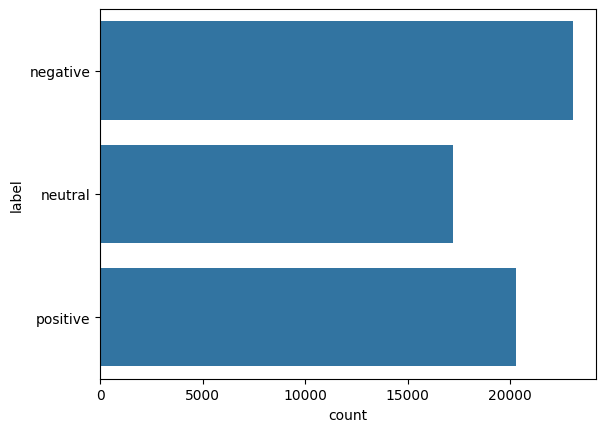

In [73]:
seaborn.countplot(pid_df['label'])

In [74]:
labels = {'negative' : 0, 'neutral' : 1, 'positive': 2}

pid_df['label'] = pid_df['label'].map(labels)
pid_df.head()

,tweet,label,clean_text
0,joke of a government na thunder way de do pres...,0,joke government na thunder way de press de wai...
1,it will not better for d handlers if this fpl ...,0,better handlers fpl thing oo fraser team start...
2,e be like say oga chairman true colour don dey...,0,like oga chairman true colour don dey cos dis ...
3,i no fit marry man wey dey fight for nxt sha n...,0,fit marry man wey dey fight nxt sha na everyda...
4,its so pathetic why dont we really think abt o...,0,pathetic dont think abt clients wen business n...


In [75]:
df_neg = pid_df[pid_df['label'] == 0]
df_neu = pid_df[pid_df['label'] == 1]
df_pos = pid_df[pid_df['label'] == 2]

In [76]:
count_negative,count_positive,count_neutral = pid_df.label.value_counts()

In [77]:
df_neu_over = df_neu.sample(count_negative, replace=True)
df_pos_over = df_pos.sample(count_negative, replace=True)


pid_overdf = pd.concat([df_neu_over, df_pos_over, df_neg])

In [78]:
pid_overdf.shape

(69126, 3)

In [79]:
print(pid_overdf['label'].value_counts())


label
1    23042
2    23042
0    23042
Name: count, dtype: int64


In [80]:
print(pid_overdf['label'].value_counts())


label
1    23042
2    23042
0    23042
Name: count, dtype: int64


In [81]:
def tokenize(text):
    return str(text).lower().split()

sentences = [tokenize(t) for t in pid_overdf['clean_text'].astype(str).tolist()]

w2v_size = 100
w2v_model = Word2Vec(
    sentences,
    vector_size=w2v_size,
    window=5,
    min_count=1,  
    workers=4,
    sg=1 
)

w2v_model.save("pidgin_word2vec.model")

In [82]:
def sentence_vector(sentence, model, size):
    tokens = tokenize(sentence)
    vecs = []
    for t in tokens:
        if t in model.wv:
            vecs.append(model.wv[t])
    if len(vecs) == 0:
        return np.zeros(size, dtype=np.float32)
    return np.mean(vecs, axis=0)

In [83]:
x = np.vstack([sentence_vector(t, w2v_model, w2v_size) for t in pid_df['clean_text'].astype(str).tolist()])
y = pid_df['label'].astype(int).values

In [84]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,stratify=y)

In [85]:
ran_model = RandomForestClassifier(n_estimators=200, random_state=42)
ran_model.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
rand_ypred = ran_model.predict(x_test)

print(classification_report(y_test, rand_ypred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      4609
           1       1.00      0.97      0.98      3446
           2       0.97      0.89      0.93      4057

    accuracy                           0.95     12112
   macro avg       0.96      0.95      0.95     12112
weighted avg       0.95      0.95      0.95     12112



In [87]:
# 1. Tokenize & pad sequences
texts = pid_overdf['clean_text'].tolist()
labels = pid_overdf['label'].values

# Parameters
max_vocab_size = 10000
max_seq_length = 50  # adjust based on sentence length distribution
embedding_dim = 100
num_classes = len(np.unique(labels))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post', truncating='post')

# Convert labels to one-hot
labels_cat = to_categorical(labels, num_classes=num_classes)

# Split data
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_cat, test_size=0.2, random_state=42, stratify=labels)

In [88]:
# --- BiLSTM Model ---
def create_bilstm_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- CNN Model ---
def create_cnn_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [89]:
# Choose model to train
model = create_bilstm_model()
# Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 269s 315ms/step - accuracy: 0.8993 - loss: 0.2570 - val_accuracy: 0.9571 - val_loss: 0.1074
Epoch 2/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 259s 312ms/step - accuracy: 0.9704 - loss: 0.0831 - val_accuracy: 0.9647 - val_loss: 0.0956
Epoch 3/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 315s 379ms/step - accuracy: 0.9817 - loss: 0.0550 - val_accuracy: 0.9675 - val_loss: 0.1131
Epoch 4/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 332s 391ms/step - accuracy: 0.9868 - loss: 0.0381 - val_accuracy: 0.9680 - val_loss: 0.1187
Epoch 5/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 310s 375ms/step - accuracy: 0.9895 - loss: 0.0289 - val_accuracy: 0.9680 - val_loss: 0.1551
Epoch 6/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 348s 408ms/step - accuracy: 0.9916 - loss: 0.0230 - val_accuracy: 0.9680 - val_loss: 0.1485
Epoch 7/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 301s 379ms/step - accuracy: 0.9929 - loss: 0.0189 - val_accuracy: 0.9687 - val_loss: 0.1818
Epoch 8/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 372s 443ms/step - accuracy: 0.9936 -

In [90]:
model2 = create_cnn_model()

# Train
history = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, accuracy = model2.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

Epoch 1/10
163/778 ━━━━━━━━━━━━━━━━━━━━ 1:27 143ms/step - accuracy: 0.7180 - loss: 0.7085

778/778 ━━━━━━━━━━━━━━━━━━━━ 132s 158ms/step - accuracy: 0.9336 - loss: 0.1803 - val_accuracy: 0.9580 - val_loss: 0.0966
Epoch 2/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 132s 145ms/step - accuracy: 0.9804 - loss: 0.0589 - val_accuracy: 0.9698 - val_loss: 0.0883
Epoch 3/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 142s 144ms/step - accuracy: 0.9913 - loss: 0.0293 - val_accuracy: 0.9700 - val_loss: 0.0971
Epoch 4/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 142s 144ms/step - accuracy: 0.9950 - loss: 0.0178 - val_accuracy: 0.9698 - val_loss: 0.1011
Epoch 5/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 147s 151ms/step - accuracy: 0.9959 - loss: 0.0134 - val_accuracy: 0.9705 - val_loss: 0.1241
Epoch 6/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 146s 155ms/step - accuracy: 0.9967 - loss: 0.0095 - val_accuracy: 0.9705 - val_loss: 0.1197
Epoch 7/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 138s 150ms/step - accuracy: 0.9965 - loss: 0.0082 - val_accuracy: 0.9687 - val_loss: 0.1382
Epoch 8/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 139s 145ms/step - accuracy: 0.9972 - loss: 0.00

In [91]:
samples = [
    "Dis fone swet die, e too sabi! 😍 #NaijaVibes",
    "Wetn be dis food? Rubbish o, I vex! 😒",
    "I dey chill for house, just dey watch tv.",
    "Chai, dis music na fire o! I dey enjoy am well, no cap. 🔥",
    "Why NEPA no gree bring light? Dis wahala too much! 😤 @SistaNgozi",
    "Dem sell cloth for market, na normal tin.",
    "OMO, DIS PARTY NA PURE BLISS! I DEY DANCE LIKE MAD! 💃",
    "Dis laptop don spoil again, I tire for dis scam! 😩 #NaijaWahala",
    "Broda dey read book for school, nothing special sha.",
    "Nawa o, dis soup dey give me joy, e choke pass! 😎 @BrosJide",
    "Dis shop cheat me, I buy fake shoe, chai, God abeg! 😢",
    "Today na Wednesday, I dey go office wey dem fix car.",
    "God bless my sista, dem sabi cook soup well, my heart dey smile! 😊",
    "Why pesin dey do me like dis? E dey vex me taya, abeg comot! 😣",
    "I dey drive for park, aunty dey gist with me, no stress.",
    "DIS FILM NA HEAVEN ON EARTH, I DEY LAUGH, E CARRY ME GO! 😍 #Blessed",
    "Chai, I don try dis bag taya, e tear, dem sell me fake o! 😭",
    "Dem dey sell food for station, I just dey pass by, no wahala.",
    "Omo, dis concert e choke! I no fit shout, e too sabi o! 🙌",
    "Dis phone na scam, I waste money, who go help me now? 😢 #NaijaWahala",
    "I dey chill for beach, friend dey play music, na so life be.",
    "Abeg, dis cloth na fire o! I dey wear am every day, e sweet pass! 😍",
    "Why dem no fix dis road? Flood dey come, nawa o, I vex! 😡",
    "Today na Friday, I dey market wey dem sell phone, nothing much.",
    "DIS MATCH NA D REAL DEAL, MY TEAM WIN, I DEY HAPPY DIE! 🙌",
    "Omo, dis rain no gree stop, my house dey leak, God abeg! 😩",
    "Uncle dey cook for kitchen, I dey observe, no big deal sha.",
    "Babe too sabi o! I love am well, e choke, no lie! 🔥 @SistaNgozi",
    "Dis oga no gree pay salary, hunger dey wire me, chai, I vex! 😭",
    "Dem dey fix shoe for shop, I dey watch, na normal tin."
]

# Prediction function for DL models (BiLSTM and CNN), based on your code
def dl_predict(model, texts):
    clean_texts = [preprocess_text(t) for t in texts]
    seqs = tokenizer.texts_to_sequences(clean_texts)
    padded = pad_sequences(seqs, maxlen=max_seq_length, padding='post', truncating='post')
    preds = model.predict(padded, verbose=0)
    classes = np.argmax(preds, axis=1)
    return [label_map[c] for c in classes]

# Label map from your code (adjust if needed)
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Predict with BiLSTM (model)
bilstm_preds = dl_predict(model, samples)
print("BiLSTM Predictions:")
for text, pred in zip(samples, bilstm_preds):
    print(f"{text} -> {pred}")

# Predict with CNN (model2)
cnn_preds = dl_predict(model2, samples)
print("\nCNN Predictions:")
for text, pred in zip(samples, cnn_preds):
    print(f"{text} -> {pred}")

BiLSTM Predictions:
Dis fone swet die, e too sabi! 😍 #NaijaVibes -> positive
Wetn be dis food? Rubbish o, I vex! 😒 -> negative
I dey chill for house, just dey watch tv. -> neutral
Chai, dis music na fire o! I dey enjoy am well, no cap. 🔥 -> positive
Why NEPA no gree bring light? Dis wahala too much! 😤 @SistaNgozi -> negative
Dem sell cloth for market, na normal tin. -> neutral
OMO, DIS PARTY NA PURE BLISS! I DEY DANCE LIKE MAD! 💃 -> negative
Dis laptop don spoil again, I tire for dis scam! 😩 #NaijaWahala -> negative
Broda dey read book for school, nothing special sha. -> positive
Nawa o, dis soup dey give me joy, e choke pass! 😎 @BrosJide -> positive
Dis shop cheat me, I buy fake shoe, chai, God abeg! 😢 -> negative
Today na Wednesday, I dey go office wey dem fix car. -> neutral
God bless my sista, dem sabi cook soup well, my heart dey smile! 😊 -> positive
Why pesin dey do me like dis? E dey vex me taya, abeg comot! 😣 -> negative
I dey drive for park, aunty dey gist with me, no stress. 

In [92]:
y_prred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_prred, target_names=['negative','neutral','positive']))

 28/433 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step

433/433 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step
              precision    recall  f1-score   support

    negative       0.96      0.95      0.95      4608
     neutral       0.99      0.99      0.99      4609
    positive       0.95      0.97      0.96      4609

    accuracy                           0.97     13826
   macro avg       0.97      0.97      0.97     13826
weighted avg       0.97      0.97      0.97     13826

